<div style="background-color: #30a31cff ; padding: 20px; border-radius: 10px;">

<h1 style="color: black; text-align: center;">
    Projet Green AI : Détection des déchets dans l'océan 
</h1>

<h5 style="color: black; text-align: center;">
    Ovia Chanemouganandam, Sandrine Daniel, Léo-Paul Chauvigné, Timothée Joliot, Hannah-May Littière et Yann Lin  – DIA 4
</h5>

</div>

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import torch
from torch.utils.data import DataLoader
import sys
import torch.nn as nn
import torch.optim as optim

from dataset import (
    MaridaDatasetLoader,
    find_patch_bases,
    do_img_conf_mask_exist,
)
from preprocessing import (
    normalize_image,
    set_low_conf_for_nan,
    apply_augmentations,
    build_conf_ignore_mask,
    apply_ignore_index_to_target,
    flatten_for_rf,
    compute_dataset_stats,
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from matplotlib.colors import LogNorm
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm
from sklearn.metrics import classification_report, f1_score, jaccard_score
from unet import UNet

# <font color='#30a31cff'> <b>1. Premières idées de projet  </b></font>

1. Première idée

Au départ, nous avions choisi une problématique liée à la prédiction du potentiel de production d’énergie solaire à partir de données météorologiques locales.

Problématique initiale :
Peut-on estimer la quantité d’énergie solaire (en kWh/m²) produite dans une zone donnée à partir de variables météorologiques telles que l’irradiation, la température, la couverture nuageuse, l’humidité ou encore la vitesse du vent ?

Cependant, ce sujet s’est révélé trop vague et ne faisait finalement pas appel à de véritables modèles d’IA. En pratique, notre approche ne consistait pas à effectuer une prédiction complexe, mais plutôt à appliquer une fonction relativement simple à partir de l’irradiation, un paramètre déjà fortement corrélé à la production solaire. La tâche devenait alors essentiellement un calcul direct plutôt qu’un apprentissage réel, ce qui limitait fortement l’intérêt et la profondeur du projet.

Nous avons beaucoup tourné autour de l'idée des panneaux solaires sans réellement trouver de problématique intéressante et challengeante

2. Deuxième idée

Nous avons essayé d'approfondir la piste que vous nous aviez suggérée :

Quelles zones géographiques présentent une évolution journalière de la consommation d’électricité qui suit le même rythme que l’ensoleillement local, indiquant un fort potentiel d’autoconsommation solaire ?

Les datasets trouvés :

eco2mix pour la consommation d’électricité par métropole
NASA POWER pour les données météorologiques horaires

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os 

1ère partie d'exploration des datasets avec l'analyse d'un exemple sur une ville en particulier. Fusion des deux datasets selon la variable datetime.

In [18]:
BASE_PATH = "data/ancien_data/"

def load_nasa_hourly(csv_path):
    """
    Charge un fichier NASA POWER horaire et renvoie un DataFrame
    avec une colonne datetime et les variables météo.
    """
    #Détecter la ligne d'entête
    header_row = None
    with open(csv_path, 'r') as f:
        for i, line in enumerate(f):
            if line.startswith("YEAR,MO,DY,HR"):
                header_row = i
                break
    if header_row is None:
        raise ValueError(f"Impossible de trouver la ligne d'entête dans {csv_path}")

    df = pd.read_csv(csv_path, header=header_row)

    #Construire un datetime
    df['datetime'] = pd.to_datetime(
        df[['YEAR', 'MO', 'DY', 'HR']].rename(
            columns={'YEAR': 'year', 'MO': 'month', 'DY': 'day', 'HR': 'hour'}
        )
    )

    #Garder juste ce qui nous intéresse
    cols_to_keep = ['datetime', 'ALLSKY_SFC_SW_DWN', 'T2M', 'RH2M', 'WS10M', 'PRECTOTCORR']
    cols_to_keep = [c for c in cols_to_keep if c in df.columns]
    df = df[cols_to_keep].sort_values('datetime')

    return df

In [19]:
def load_eco2mix_metropole(csv_path, metropole_name):
    """
    Charge le fichier eco2mix-metropoles-tr filtré sur une métropole.
    Renvoie un DataFrame avec datetime + consommation (MW).
    """
    df = pd.read_csv(csv_path, sep=';')

    #Filtrer la métropole voulue
    df = df[df['Métropole'] == metropole_name].copy()

    #Convertir la colonne Date  Heure en datetime
    df['datetime'] = pd.to_datetime(df['Date - Heure'])
    df = df.sort_values('datetime')

    # Garder les colonnes importantes
    df = df[['datetime', 'Consommation (MW)']]

    return df

In [32]:
ECO2MIX_PATH = "/home/ovia/satellite_image_ocean_trash_detector/data/ancien_data/eco2mix-metropoles-tr.csv"

df_nasa = load_nasa_hourly("/home/ovia/satellite_image_ocean_trash_detector/data/ancien_data/Bordeaux_POWER_Point_Hourly_20220101_20241231_044d84N_000d58W_LST.csv")

df_eco = pd.read_csv(ECO2MIX_PATH, sep=';')

metropole_name = "Bordeaux Métropole"
df_eco = df_eco[df_eco['Métropole'] == metropole_name].copy()


df_eco['datetime'] = pd.to_datetime(df_eco['Date - Heure'], utc=True, errors='coerce')

#enlever les lignes mal parsées (au cas où)
df_eco = df_eco.dropna(subset=['datetime'])


df_eco['datetime'] = (
    df_eco['datetime']
    .dt.tz_convert('Europe/Paris')   # passer en heure locale
    .dt.tz_localize(None)           # enlever l'info de fuseau
)


print(df_eco['datetime'].dtype)


df_eco = df_eco.set_index('datetime')

print(type(df_eco.index), df_eco.index.dtype)

eco_hourly = (
    df_eco
    .resample('h')['Consommation (MW)']
    .mean()
    .reset_index()
)

eco_hourly.head()

datetime64[ns]
<class 'pandas.core.indexes.datetimes.DatetimeIndex'> datetime64[ns]


,datetime,Consommation (MW)
0,2022-01-01 00:00:00,678.75
1,2022-01-01 01:00:00,681.50
2,2022-01-01 02:00:00,684.25
3,2022-01-01 03:00:00,645.50
4,2022-01-01 04:00:00,623.25


In [33]:
# NASA est déjà horaire mais on s'assure que c'est propre
nasa_hourly = (
    df_nasa
    .set_index('datetime')
    .resample('h').mean()
    .reset_index()
)
nasa_hourly.head()

,datetime,ALLSKY_SFC_SW_DWN,T2M,RH2M,WS10M,PRECTOTCORR
0,2022-01-01 00:00:00,0.0,6.50,100.00,3.54,0.36
1,2022-01-01 01:00:00,0.0,6.26,100.00,3.63,0.26
2,2022-01-01 02:00:00,0.0,6.24,96.51,3.80,0.17
3,2022-01-01 03:00:00,0.0,6.27,88.60,3.91,0.02
4,2022-01-01 04:00:00,0.0,6.23,82.33,3.75,0.02


In [34]:
#Fusion sur datetime (inner pour garder les heures communes)
df_merged = pd.merge(
    eco_hourly,
    nasa_hourly,
    on='datetime',
    how='inner'
)

df_merged.head()

,datetime,Consommation (MW),ALLSKY_SFC_SW_DWN,T2M,RH2M,WS10M,PRECTOTCORR
0,2022-01-01 00:00:00,678.75,0.0,6.50,100.00,3.54,0.36
1,2022-01-01 01:00:00,681.50,0.0,6.26,100.00,3.63,0.26
2,2022-01-01 02:00:00,684.25,0.0,6.24,96.51,3.80,0.17
3,2022-01-01 03:00:00,645.50,0.0,6.27,88.60,3.91,0.02
4,2022-01-01 04:00:00,623.25,0.0,6.23,82.33,3.75,0.02


Après avoir fait de premiers tests avec les datasets d'une ville en particulier et avoir bien réussi à les fusionner on va pouvoir s'étendre à toutes nos villes en construisant des fonctions pour répéter le processus d'importation et de fusion de dataset pour chaque ville.

In [ ]:
# Dictionnaire NASA pour plusieurs villes
NASA_FILES = {
    "Bordeaux Métropole": os.path.join(
        BASE_PATH,
        "Bordeaux_POWER_Point_Hourly_20220101_20241231_044d84N_000d58W_LST.csv"
    ),
    "Métropole de Lyon": os.path.join(
        BASE_PATH,
        "Lyon_POWER_Point_Hourly_20220101_20241231_045d77N_004d83E_LST.csv"
    ),
    "Métropole Européenne de Lille": os.path.join(
        BASE_PATH,
        "Lille_POWER_Point_Hourly_20220101_20241231_050d63N_003d06E_LST.csv"
    ),
    "Métropole d'Aix-Marseille-Provence": os.path.join(
        BASE_PATH,
        "Marseille_POWER_Point_Hourly_20220101_20241231_043d29N_005d37E_LST.csv"
    ),
    "Métropole du Grand Paris": os.path.join(
        BASE_PATH,
        "Paris_POWER_Point_Hourly_20220101_20241231.csv"
    ),
    "Dijon Métropole": os.path.join(
        BASE_PATH,
        "Dijon_POWER_Point_Hourly_20220101_20241231_047d33N_005d04E_LST.csv"
    ),
}

def load_eco2mix_hourly_for_metropole(csv_path, metropole_name):
    """
    Charge eco2mix pour une métropole, convertit la date en Europe/Paris
    et agrège en horaire.
    """
    df = pd.read_csv(csv_path, sep=';')
    df = df[df['Métropole'] == metropole_name].copy()

    # Datetime avec timezone + conversion Europe/Paris
    df['datetime'] = pd.to_datetime(df['Date - Heure'], utc=True, errors='coerce')
    df = df.dropna(subset=['datetime'])
    df['datetime'] = df['datetime'].dt.tz_convert('Europe/Paris').dt.tz_localize(None)

    #Agrégation horaire
    df = (
        df.set_index('datetime')
          .resample('h')['Consommation (MW)']
          .mean()
          .reset_index()
    )
    return df

def build_merged_for_city(metropole_name):
    """
    Charge NASA + eco2mix pour une ville, met tout à l'heure
    et renvoie un df fusionné avec :
      datetime, Consommation (MW), ALLSKY_SFC_SW_DWN, ...
    """
    nasa_path = NASA_FILES[metropole_name]
    df_nasa = load_nasa_hourly(nasa_path)
    df_eco_hourly = load_eco2mix_hourly_for_metropole(ECO2MIX_PATH, metropole_name)

    nasa_hourly = (
        df_nasa
        .set_index('datetime')
        .resample('h')
        .mean()
        .reset_index()
    )

    df_merged = pd.merge(
        df_eco_hourly,
        nasa_hourly,
        on='datetime',
        how='inner'
    )
    return df_merged

# <font color='#30a31cff'> <b>1. Pré-processing  </b></font>

1. Définition des chemins

In [2]:
PROJECT_PATH = os.path.join(os.getcwd(), "../")
# On ajoute 'src' au système pour les imports
sys.path.append(os.path.join(PROJECT_PATH, "src"))

# On définit les chemins de données

DATA_ROOT = os.path.join(os.getcwd(), "../","data", "raw","MARIDA")
PATCHES_DIR = os.path.join(DATA_ROOT, "patches")
SPLITS_DIR = os.path.join(DATA_ROOT, "splits")

print(f" Dossier Patches : {PATCHES_DIR}")
print(f" Dossier Textes : {SPLITS_DIR}")

 Dossier Patches : /home/leopa/projects/satellite_image_ocean_trash_detector/src/../data/raw/MARIDA/patches
 Dossier Textes : /home/leopa/projects/satellite_image_ocean_trash_detector/src/../data/raw/MARIDA/splits


2. Transformation et fonctions utilitaires

In [3]:
def train_transform(img, mask, conf):
    img, conf = set_low_conf_for_nan(img, conf, low_conf_level=3)
    img = normalize_image(img)
    img, mask, conf = apply_augmentations(img, mask, conf)
    return img, mask, conf

def val_transform(img, mask, conf):
    img, conf = set_low_conf_for_nan(img, conf, low_conf_level=3)
    img = normalize_image(img)
    return img, mask, conf

def get_valid_bases(split_filename, patches_root):
    split_path = os.path.join(SPLITS_DIR, split_filename)
    if not os.path.exists(split_path):
        print(f" Fichier texte manquant : {split_path}")
        return []

    valid_bases = []
    with open(split_path, 'r') as f:
        lines = f.readlines()

    print(f" Lecture de {split_filename}...")
    for line in lines:
        name = line.strip()
        if not name: continue

        # Correction du nom : Ajout de S2_
        base_name = "S2_" + name
        folder_name = base_name.rsplit('_', 1)[0]
        relative_path = os.path.join(folder_name, base_name)

        # Vérification
        if os.path.exists(os.path.join(patches_root, relative_path + ".tif")):
            valid_bases.append(relative_path)

    print(f"    {len(valid_bases)} images trouvées.")
    return valid_bases

In [4]:
def build_conf_ignore_mask(conf: torch.Tensor, threshold: int = 2,
    ) -> torch.Tensor:
    """
    Build a boolean mask where pixels with confidence > threshold are ignored.
    1: High - keep
    2: Moderate - keep
    3: Low - we ignore
    Args:
        conf: (H, W) integer confidence levels.
        threshold: keep pixels with conf <= threshold.
    Returns:
        ignore_mask: (H, W) bool tensor, True = IGNORE this pixel.
    """
    ignore_mask = conf > threshold
    return ignore_mask


def apply_ignore_index_to_target( target: torch.Tensor, ignore_mask: torch.Tensor, ignore_index: int = -100,
    ) -> torch.Tensor:
    """
    The function sets target pixels to ignore_index where ignore_mask is True.
    Args:
        target: (H, W) class ids.
        ignore_mask: (H, W) bool.
        ignore_index: value used in loss 
    Returns:
        target_mod: (H, W) with some pixels set to ignore_index.
    """
    target_mod = target.clone()
    target_mod[ignore_mask] = ignore_index
    return target_mod

3. Création des listes d'images et des DataLoaders

In [5]:
train_bases = get_valid_bases("train_X.txt", PATCHES_DIR)
val_bases = get_valid_bases("val_X.txt", PATCHES_DIR)

if len(train_bases) == 0:
    raise ValueError(" ERREUR : Aucune image trouvée. Vérifiez le chemin DATA_ROOT.")

train_dataset = MaridaDatasetLoader(PATCHES_DIR, train_bases, transform=train_transform)
val_dataset = MaridaDatasetLoader(PATCHES_DIR, val_bases, transform=val_transform)

BATCH_SIZE = 8
num_workers = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers)

 Lecture de train_X.txt...
    694 images trouvées.
 Lecture de val_X.txt...
    328 images trouvées.


# <font color='#30a31cff'> <b>2. Application des modèles  </b></font>

## **Modèle 1 : U-Net** 

1. Pondération des classes 

On donne un gros poids aux classes rares (Débris, Mousse) et un petit poids aux classes fréquentes (Eau)
Débris (Class 0) a un poids de 50, l'Eau (Class 7) a un poids de 0.1

In [6]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Démarrage sur : {DEVICE}")

 Démarrage sur : cuda


In [7]:
class_weights = torch.tensor([
    50.0,  # 0: Débris Marins (TRÈS IMPORTANT)
    5.0,   # 1: Sargasses Denses
    10.0,  # 2: Sargasses Éparses
    20.0,  # 3: Matière Organique (Rare)
    5.0,   # 4: Navire
    0.5,   # 5: Nuages (Fréquent, facile)
    0.2,   # 6: Eau Marine (Très fréquent)
    0.1,   # 7: Eau Sédimentaire (Trop fréquent, on le calme)
    20.0,  # 8: Écume (Difficile, ressemble au plastique)
    0.5,   # 9: Eau Trouble
    10.0,  # 10: Eau Peu Profonde
    10.0,  # 11: Vagues
    5.0,   # 12: Ombre
    5.0,   # 13: Sillage
    10.0   # 14: Mixte
]).to(DEVICE)

2. Modèle, loss et optimizer

In [8]:
model = UNet(n_channels=11, n_classes=15).to(DEVICE)

# Optimiseur
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Loss avec poids + ignore_index
criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)

EPOCHS = 15 

print("Loss pondérée activée : les débris sont 50x plus importants que l'eau.")

Loss pondérée activée : les débris sont 50x plus importants que l'eau.


3. Boucle d'entraînement

In [9]:
print("\n Lancement de la boucle d'entraînement...")

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for img, mask, conf in loop:
        img = img.to(DEVICE)
        mask = mask.to(DEVICE)
        conf = conf.to(DEVICE)

        ignore_mask = build_conf_ignore_mask(conf, threshold=2)
        target = apply_ignore_index_to_target(mask, ignore_mask, ignore_index=-100)

        valid = (target != -100)
        target[valid] = target[valid] - 1
        target[target == -1] = -100

        optimizer.zero_grad()
        outputs = model(img)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    # Sauvegarde sur le Drive
    save_dir = os.path.join(PROJECT_PATH, "models")
    os.makedirs(save_dir, exist_ok=True)
    torch.save(model.state_dict(), os.path.join(save_dir, "mon_unet_latest.pth"))

print(" Entraînement terminé et modèle sauvegardé !")


 Lancement de la boucle d'entraînement...


Epoch 15/15: 100%|██████████| 87/87 [00:21<00:00,  4.11it/s, loss=0.477]

 Entraînement terminé et modèle sauvegardé !


4. Noms des classes

In [10]:
CLASS_NAMES = {
    0: 'Débris Marins',
    1: 'Sargasses Denses',
    2: 'Sargasses Éparses',
    3: 'Matière Organique',
    4: 'Navire',
    5: 'Nuages',
    6: 'Eau Marine',
    7: 'Eau Sédimentaire',
    8: 'Écume',
    9: 'Eau Trouble',
    10: 'Eau Peu Profonde',
    11: 'Vagues',
    12: 'Ombre',
    13: 'Sillage',
    14: 'Mixte'
}
target_names = [CLASS_NAMES[i] for i in range(15)]

5. Evaluation

In [11]:
def evaluate_model_complete(model, loader, device):
    print("Calcul des scores en cours (F1, IoU, Précision)...")
    model.eval()

    y_true_list = []
    y_pred_list = []

    with torch.no_grad():
        for img, mask, conf in tqdm(loader, desc="Validation"):
            img = img.to(device)
            mask = mask.to(device)
            conf = conf.to(device)

            # Même logique que pour l'entraînement
            ignore_mask = build_conf_ignore_mask(conf, threshold=2)
            target = apply_ignore_index_to_target(mask, ignore_mask, ignore_index=-100)

            valid_pixels = (target != -100)
            target[valid_pixels] = target[valid_pixels] - 1
            target[target == -1] = -100

            outputs = model(img)
            preds = torch.argmax(outputs, dim=1)  # (B, H, W)

            # On ne garde que les pixels valides
            valid_mask = (target != -100)
            y_true_list.append(target[valid_mask].cpu().numpy())
            y_pred_list.append(preds[valid_mask].cpu().numpy())

    y_true = np.concatenate(y_true_list)
    y_pred = np.concatenate(y_pred_list)

    print("\n---  RÉSULTATS ---")
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"F1-Score (Macro) : {f1:.4f}")

    iou = jaccard_score(y_true, y_pred, average='macro')
    print(f"Mean IoU : {iou:.4f}")

    print("\n--- RAPPORT DÉTAILLÉ PAR CLASSE ---")
    print(classification_report(y_true, y_pred, target_names=target_names, digits=3))


# Lancement de l'évaluation
evaluate_model_complete(model, val_loader, DEVICE)

Calcul des scores en cours (F1, IoU, Précision)...


Validation: 100%|██████████| 41/41 [00:03<00:00, 10.59it/s]



---  RÉSULTATS ---
F1-Score (Macro) : 0.4535
Mean IoU : 0.3615

--- RAPPORT DÉTAILLÉ PAR CLASSE ---
                   precision    recall  f1-score   support

    Débris Marins      0.109     0.905     0.194       937
 Sargasses Denses      1.000     0.763     0.865      1167
Sargasses Éparses      0.372     0.387     0.379       375
Matière Organique      0.000     0.000     0.000        65
           Navire      0.752     0.863     0.804      1340
           Nuages      0.984     0.708     0.823     19262
       Eau Marine      0.804     0.132     0.227     18839
 Eau Sédimentaire      1.000     0.991     0.996    125565
            Écume      0.328     0.906     0.482       362
      Eau Trouble      0.954     0.910     0.932     38566
 Eau Peu Profonde      0.122     0.865     0.214      1011
           Vagues      0.200     0.942     0.330       987
            Ombre      0.176     0.652     0.277      2404
          Sillage      0.241     0.281     0.259      1946
            M

6. Matrice de confusion 

 Calcul de la matrice de confusion en cours...


Validation: 100%|██████████| 41/41 [00:03<00:00, 10.79it/s]


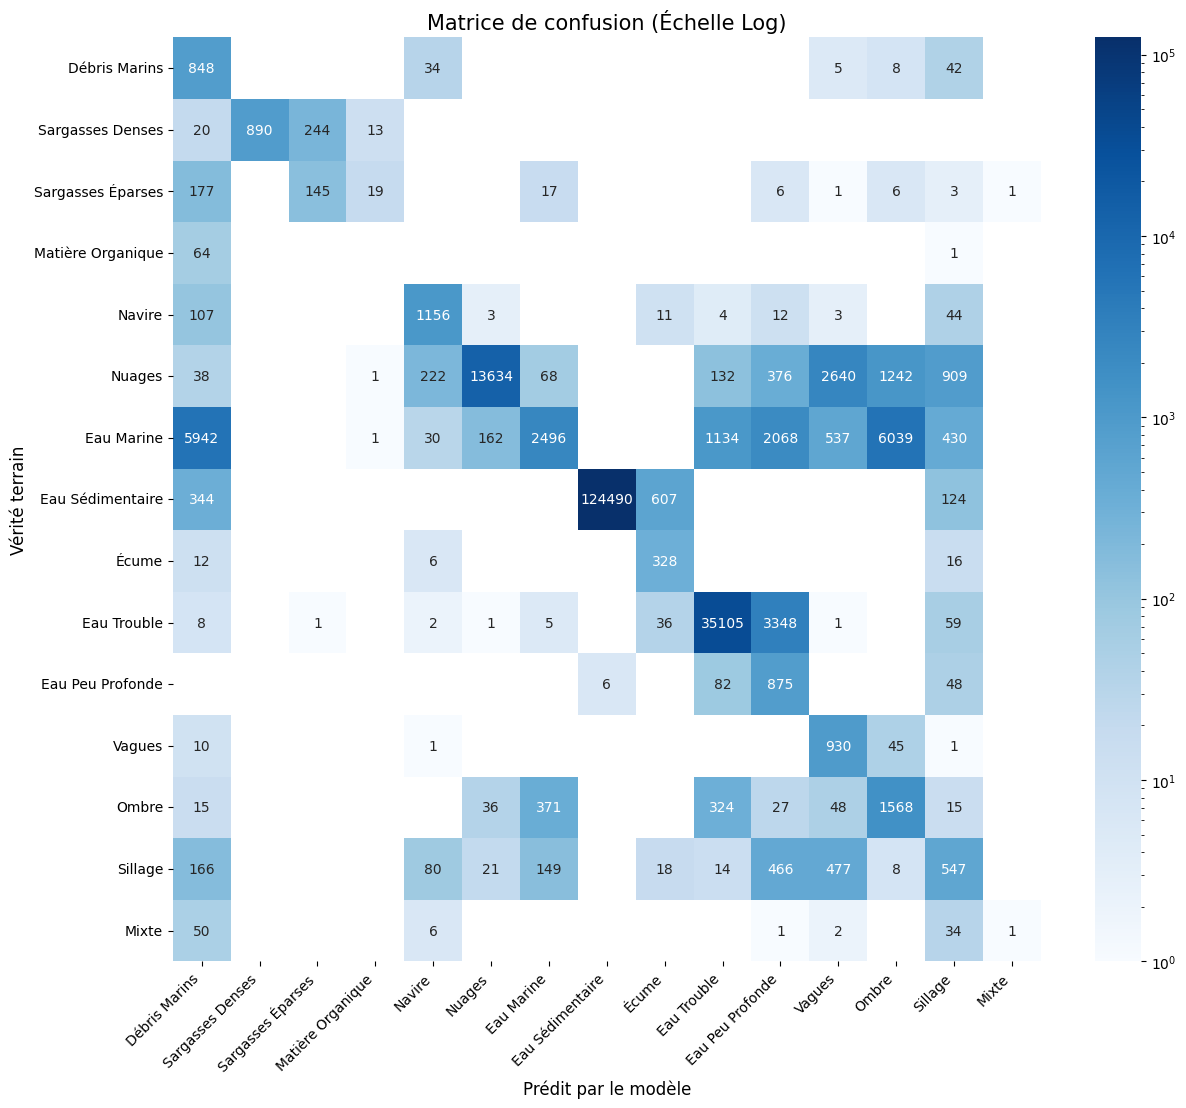

In [12]:
class_names = [CLASS_NAMES[i] for i in range(15)]


def plot_confusion_matrix(model, loader, device):
    print(" Calcul de la matrice de confusion en cours...")
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for img, mask, conf in tqdm(loader, desc="Validation"):
            img = img.to(device)
            mask = mask.to(device)
            conf = conf.to(device)

            # Même pipeline que train/éval
            ignore_mask = build_conf_ignore_mask(conf, threshold=2)
            target = apply_ignore_index_to_target(mask, ignore_mask, ignore_index=-100)

            valid_pixels = (target != -100)
            target[valid_pixels] = target[valid_pixels] - 1
            target[target == -1] = -100

            outputs = model(img)
            preds = torch.argmax(outputs, dim=1)

            mask_valide = (target != -100)
            all_preds.append(preds[mask_valide].cpu().numpy())
            all_targets.append(target[mask_valide].cpu().numpy())

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_targets)

    cm = confusion_matrix(y_true, y_pred, labels=range(15))

    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        norm=LogNorm()
    )
    plt.xlabel('Prédit par le modèle', fontsize=12)
    plt.ylabel('Vérité terrain', fontsize=12)
    plt.title('Matrice de confusion (Échelle Log)', fontsize=15)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.show()


# Lancement
plot_confusion_matrix(model, val_loader, DEVICE)

## **Modèle 2 : ResNet**

In [13]:
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as F

1. Modèle ResNet de segmentation

In [14]:
class ResNetSeg(nn.Module):
    """
    Modèle de segmentation basé sur ResNet34 :
    - Encoder : ResNet34
    - Decoder simple : conv 1x1 + upsample bilinéaire à la taille d'entrée
    Adapté à 11 canaux en entrée et 15 classes en sortie.
    """
    def __init__(self, n_channels=11, n_classes=15):
        super().__init__()

        # On part d'un ResNet34 de torchvision (non pré-entraîné pour éviter les soucis de poids)
        base = models.resnet34(weights=None)
        enc_out_channels = 512  # dimension finale de feature map

        # Adapter la première couche à 11 canaux au lieu de 3
        old_conv = base.conv1
        base.conv1 = nn.Conv2d(
            n_channels,
            old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False,
        )
        # Init Kaiming pour la nouvelle conv
        nn.init.kaiming_normal_(base.conv1.weight, mode="fan_out", nonlinearity="relu")

        # On garde les blocs du ResNet comme "encoder"
        self.stem = nn.Sequential(
            base.conv1,
            base.bn1,
            base.relu,
            base.maxpool,
        )
        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = base.layer3
        self.layer4 = base.layer4

        # Tête de segmentation : conv 1x1 vers n_classes
        self.classifier = nn.Conv2d(enc_out_channels, n_classes, kernel_size=1)

    def forward(self, x):
        # On garde la taille d'entrée pour upsample ensuite
        input_size = x.shape[-2:]  # (H, W)

        x = self.stem(x)      # /4
        x = self.layer1(x)    # /4
        x = self.layer2(x)    # /8
        x = self.layer3(x)    # /16
        x = self.layer4(x)    # /32

        logits = self.classifier(x)  # (B, n_classes, H/32, W/32)

        # Upsampling bilinéaire jusqu'à la taille d'entrée
        logits = F.interpolate(
            logits,
            size=input_size,
            mode="bilinear",
            align_corners=False
        )
        return logits

2. Instanciation, loss et optimizer

Ici, on réutilise DEVICE, class_weights et le même type de loss que pour U-Net

In [15]:
model_resnet = ResNetSeg(n_channels=11, n_classes=15).to(DEVICE)

optimizer_resnet = optim.Adam(model_resnet.parameters(), lr=1e-4)

# loss pondérée
criterion_resnet = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)

EPOCHS_RESNET = 15
print("Modèle ResNetSeg initialisé avec loss pondérée (débris très importants).")

Modèle ResNetSeg initialisé avec loss pondérée (débris très importants).


3. Boucle d'entraînement

In [16]:
print("\n Lancement de la boucle d'entraînement (ResNetSeg)...")

for epoch in range(EPOCHS_RESNET):
    model_resnet.train()
    epoch_loss = 0.0
    loop = tqdm(train_loader, desc=f"[ResNet] Epoch {epoch+1}/{EPOCHS_RESNET}")

    for img, mask, conf in loop:
        img = img.to(DEVICE)
        mask = mask.to(DEVICE)
        conf = conf.to(DEVICE)

        # Même pipeline que pour le U-Net
        ignore_mask = build_conf_ignore_mask(conf, threshold=2)
        target = apply_ignore_index_to_target(mask, ignore_mask, ignore_index=-100)

        valid = (target != -100)
        target[valid] = target[valid] - 1
        target[target == -1] = -100

        optimizer_resnet.zero_grad()
        outputs = model_resnet(img)          # (B, 15, H, W)
        loss = criterion_resnet(outputs, target)
        loss.backward()
        optimizer_resnet.step()

        epoch_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    # Sauvegarde du modèle ResNet après chaque epoch
    save_dir = os.path.join(PROJECT_PATH, "models")
    os.makedirs(save_dir, exist_ok=True)
    torch.save(model_resnet.state_dict(), os.path.join(save_dir, "resnet_seg_latest.pth"))

print(" Entraînement ResNet terminé et modèle sauvegardé !")


 Lancement de la boucle d'entraînement (ResNetSeg)...


[ResNet] Epoch 15/15: 100%|██████████| 87/87 [00:05<00:00, 16.83it/s, loss=1.84] 


 Entraînement ResNet terminé et modèle sauvegardé !


4. Evaluation du modèle 

In [17]:
# On réutilise la même fonction d'évaluation que pour U-net
evaluate_model_complete(model_resnet, val_loader, DEVICE)

Calcul des scores en cours (F1, IoU, Précision)...


Validation: 100%|██████████| 41/41 [00:01<00:00, 22.28it/s]



---  RÉSULTATS ---
F1-Score (Macro) : 0.2215
Mean IoU : 0.1822

--- RAPPORT DÉTAILLÉ PAR CLASSE ---
                   precision    recall  f1-score   support

    Débris Marins      0.036     0.852     0.070       937
 Sargasses Denses      0.000     0.000     0.000      1167
Sargasses Éparses      0.000     0.000     0.000       375
Matière Organique      0.000     0.000     0.000        65
           Navire      0.473     0.113     0.182      1340
           Nuages      0.955     0.442     0.604     19262
       Eau Marine      0.000     0.000     0.000     18839
 Eau Sédimentaire      1.000     0.960     0.980    125565
            Écume      0.010     0.030     0.015       362
      Eau Trouble      0.939     0.958     0.948     38566
 Eau Peu Profonde      0.034     0.428     0.063      1011
           Vagues      0.057     0.083     0.067       987
            Ombre      0.243     0.447     0.315      2404
          Sillage      0.105     0.064     0.080      1946
            M

/home/leopa/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leopa/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leopa/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


5. Matrice d confusion 

 Calcul de la matrice de confusion en cours...


Validation: 100%|██████████| 41/41 [00:01<00:00, 23.17it/s]


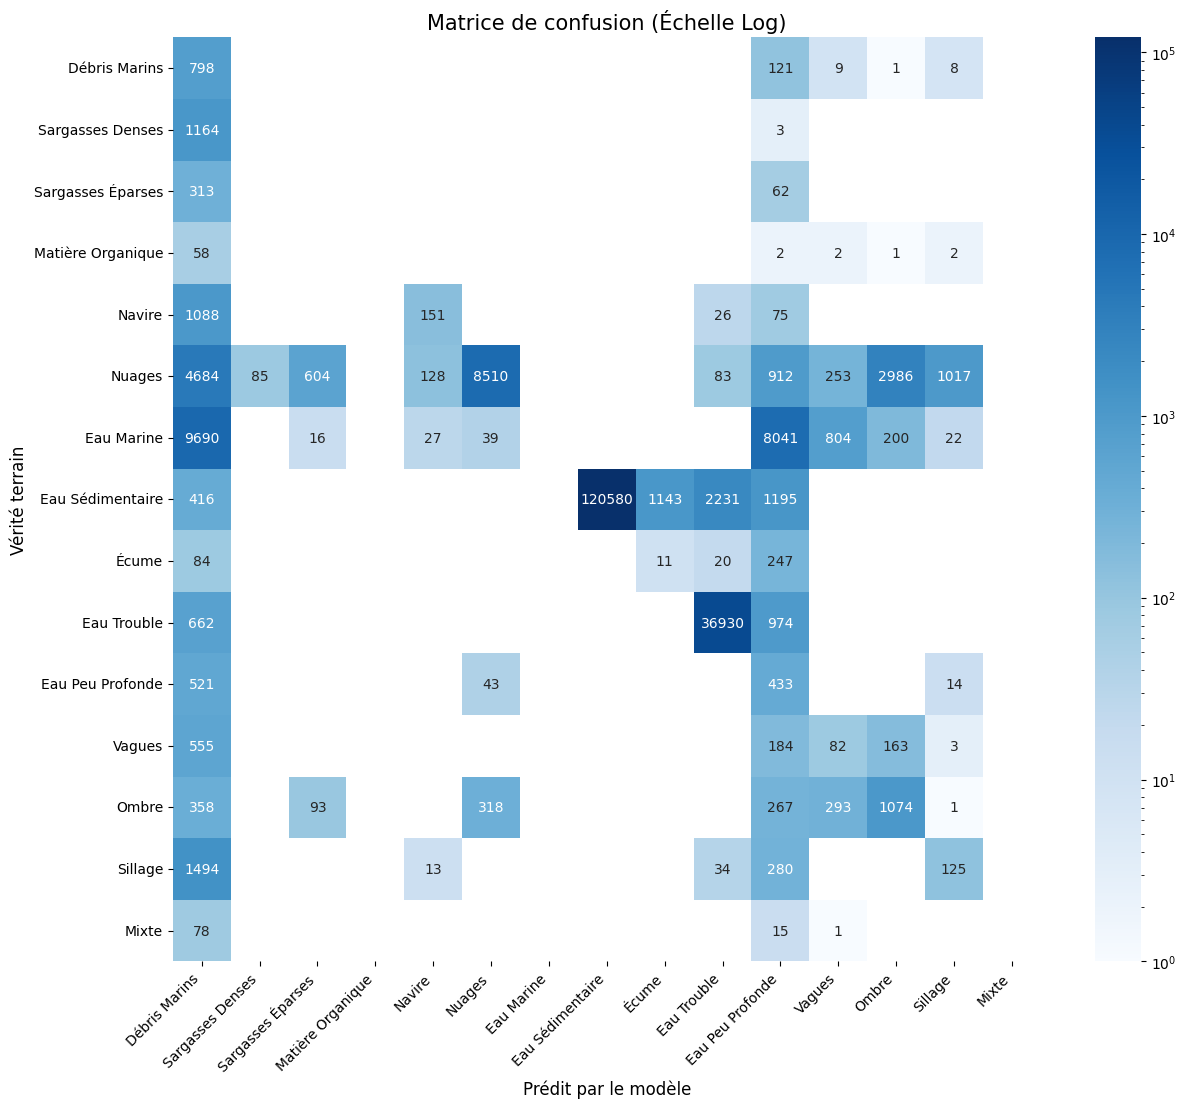

In [18]:
plot_confusion_matrix(model_resnet, val_loader, DEVICE)